## Train a base model using overlapping classes selected by movements

In [1]:
import os
import json
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization, Bidirectional, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from keras.utils import plot_model
from collections import Counter



2025-04-13 22:41:29.434078: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-13 22:41:30.517247: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# check if the gpu support available
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-04-13 22:41:31.397906: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-13 22:41:31.534340: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-13 22:41:31.534520: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [3]:
data_directory = '../all_outputs/output_include'

# list all the files in directories and sub directories in in data_direcotiry and store them list_list list
file_names = []

for root, _, files in os.walk(data_directory):  # Walk through all directories and subdirectories
        for filename in files:
            file_names.append(os.path.join(root, filename))

print(len(file_names))            

4022


In [7]:
# Shape of dataset (videos, frames, landmarks_fflattened)
# Number of videos = number of files in data_directory
# We take X frames from each video
# 

all_data = []

In [8]:
# Define indices for points of interest
pose_indices = [0, 15, 16, 17, 18, 19, 20]
hand_indices = [0, 4, 7, 8, 11, 12, 15, 16, 19, 20]

In [9]:

def load_landmarks(filenames, num_frames, glossIndex = 4):
    
    
    # Prepare storage for data and labels
    video_data = []
    labels = []
    
    for file in filenames:
     
        # print(file)
        gloss = file.split('/')[glossIndex]
        # print(gloss)


        with open(file, 'rb') as f:
                landmarks = pickle.load(f)
                    
                # Prepare frame storage for each video with fixed number of frames
                frames = []

                # Get frame sampling step (skip frames if necessary)
                total_frames = len(landmarks)
                step = max(1, total_frames // num_frames)
                    
                # Process frames
                for i in range(num_frames):
                    frame_index = i * step if total_frames >= num_frames else i
                    
                    if frame_index < total_frames:
                        frame = landmarks[frame_index]
                    else:
                        frame = None
                        
                    # Extract and flatten required points
                    pose_points = frame['pose_landmarks'] if frame and frame['pose_landmarks'] else [None] * 33
                    left_hand_points = frame['left_hand_landmarks'] if frame and frame['left_hand_landmarks'] else [None] * 21
                    right_hand_points = frame['right_hand_landmarks'] if frame and frame['right_hand_landmarks'] else [None] * 21
                        
                    # Collect only specified indices and flatten them
                    extracted_points = []

                    # Collect pose points first
                    for idx in pose_indices:
                        point = pose_points[idx] if pose_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    # print(left_hand_points)
                    for idx in hand_indices:
                        point = left_hand_points[idx] if left_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])

                    # Collect right hand points
                    for idx in hand_indices:
                        point = right_hand_points[idx] if right_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    frames.append(extracted_points)
                    
                # Add the processed video frames to the main array
                video_data.append(frames)
                labels.append(gloss)
                

    # Convert to numpy arrays
    video_data = np.array(video_data)
    labels = np.array(labels)
    
    return video_data, labels

# Example usage
num_frames = 30  # Desired fixed number of frames per video

video_data, labels = load_landmarks(file_names, num_frames)

# `video_data` has shape (number of videos, num_frames, number of points*2) where points*2 is the flattened landmark count
# `labels` contains the labels for each video


In [12]:
NUM_CLASSES = len(set(labels))
NUM_CLASSES

242

In [13]:
set(labels)

{'Actor',
 'Adult',
 'Afternoon',
 'Alright',
 'Animal',
 'Artist',
 'Attack',
 'Author',
 'Baby',
 'Bag',
 'Ball',
 'Bank',
 'Bathroom',
 'Beautiful',
 'Bed',
 'Bedroom',
 'Bill',
 'Bird',
 'Black',
 'Blind',
 'Blue',
 'Book',
 'Box',
 'Boy',
 'Brother',
 'Brown',
 'Camera',
 'Car',
 'Card',
 'Cat',
 'Cell phone',
 'Chair',
 'Child',
 'City',
 'Clock',
 'Clothing',
 'Colour',
 'Computer',
 'Court',
 'Cow',
 'Crowd',
 'Daughter',
 'Deaf',
 'Death',
 'Doctor',
 'Dog',
 'Door',
 'Dream',
 'Dress',
 'Election',
 'Energy',
 'Evening',
 'Exercise',
 'Fall',
 'Family',
 'Fan',
 'Father',
 'Fish',
 'Friday',
 'Friend',
 'Gift',
 'Girl',
 'God',
 'Good_Morning',
 'Good_afternoon',
 'Good_evening',
 'Good_night',
 'Grandfather',
 'Grandmother',
 'Green',
 'Grey',
 'Ground',
 'Gun',
 'Hat',
 'Hello',
 'Horse',
 'Hospital',
 'Hour',
 'House',
 'How_are_you',
 'Husband',
 'I',
 'India',
 'Job',
 'Key',
 'King',
 'Kitchen',
 'Lamp',
 'Laptop',
 'Lawyer',
 'Letter',
 'Library',
 'Location',
 'Lock',

### Use this block if you need to skip overlapping words

In [15]:
CUSTOM_NUM_CLASSES = 80


# Count the occurrences of each class
class_counts = Counter(labels)

# Sort classes by their counts in descending order and select the top 120 classes
top_classes = [cls for cls, count in class_counts.most_common(CUSTOM_NUM_CLASSES)]

# Get the counts of the top classes and find the minimum
top_class_counts = [count for cls, count in class_counts.most_common(CUSTOM_NUM_CLASSES)]
min_instances = min(top_class_counts)
print(f"Min instances top {CUSTOM_NUM_CLASSES} classes: {min_instances}")

# Filter the dataset to keep only the samples belonging to the top 120 classes
filtered_indices = [i for i, label in enumerate(labels) if label in top_classes]
video_data_filtered = video_data[filtered_indices]
labels_filtered = labels[filtered_indices]

# Encode labels after filtering
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels_filtered)
labels_one_hot = to_categorical(labels_encoded, num_classes=len(top_classes))

# Split dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(video_data_filtered, labels_one_hot, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.6, random_state=42)

# Print train, val, test shapes
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

NUM_CLASSES = CUSTOM_NUM_CLASSES


Min instances top 80 classes: 20
(1003, 30, 54) (1003, 80)
(268, 30, 54) (268, 80)
(402, 30, 54) (402, 80)


### Use this block if you need to keep overlapping words

In [16]:
CUSTOM_NUM_CLASSES = 80
Overlapping_words = ['T-Shirt', 'War', 'Train', 'Afternoon', 'Chair',
 'Bird', 'Animal', 'big_large', 'wide', 'new', 'Science', 'Fish', 'healthy', 'Newspaper','Year',
 'I',
 'God', 'old', 'Pleased',
 'Bathroom',
 'fast'] # Your list of overlapping words

# Count the occurrences of each class
class_counts = Counter(labels)

# Step 1: Find the top 80 classes based solely on instance counts
top_80_classes = [cls for cls, count in class_counts.most_common(CUSTOM_NUM_CLASSES)]

# Step 2: Ensure Overlapping_words are included in the selected classes
overlapping_set = set(Overlapping_words)

# Get the classes not in Overlapping_words
non_overlapping_classes = [cls for cls in class_counts if cls not in overlapping_set]

# Determine how many additional classes to select
num_additional_classes = CUSTOM_NUM_CLASSES - len(overlapping_set)

# Select the top classes from non_overlapping_classes based on instance counts
top_additional_classes = [
    cls for cls, count in Counter({k: class_counts[k] for k in non_overlapping_classes}).most_common(num_additional_classes)
]

# Combine overlapping classes and top additional classes
selected_classes = list(overlapping_set) + top_additional_classes

# Step 3: Find overlapping words not in the top 80 but still selected
overlapping_not_in_top_80 = [word for word in overlapping_set if word not in top_80_classes]

# Step 4: Print overlapping words not in top 80 with details
print(f"Overlapping words included despite not being in top {CUSTOM_NUM_CLASSES}:")
for word in overlapping_not_in_top_80:
    print(f"{word}: {class_counts[word]} instances")
print(f"Number of such words: {len(overlapping_not_in_top_80)}")

# Additional info: Minimum instances in selected classes
selected_class_counts = [class_counts[cls] for cls in selected_classes]
min_instances = min(selected_class_counts)
print(f"Minimum instances in selected {CUSTOM_NUM_CLASSES} classes: {min_instances}")

# Filter dataset to keep only samples from selected classes
filtered_indices = [i for i, label in enumerate(labels) if label in selected_classes]
video_data_filtered = video_data[filtered_indices]
labels_filtered = labels[filtered_indices]

# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels_filtered)
labels_one_hot = to_categorical(labels_encoded, num_classes=len(selected_classes))

# Split dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(video_data_filtered, labels_one_hot, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.6, random_state=42)

# Print dataset shapes
print("Train shapes:", X_train.shape, y_train.shape)
print("Validation shapes:", X_val.shape, y_val.shape)
print("Test shapes:", X_test.shape, y_test.shape)

# Update NUM_CLASSES for downstream use
NUM_CLASSES = len(selected_classes)

Overlapping words included despite not being in top 80:
Year: 15 instances
Animal: 20 instances
Afternoon: 14 instances
Newspaper: 14 instances
Science: 14 instances
God: 14 instances
War: 14 instances
Chair: 14 instances
Bathroom: 14 instances
Fish: 20 instances
Number of such words: 10
Minimum instances in selected 80 classes: 14
Train shapes: (975, 30, 54) (975, 80)
Validation shapes: (260, 30, 54) (260, 80)
Test shapes: (391, 30, 54) (391, 80)


In [17]:
def augment_data(x):
    # Add random noise to the input
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.01)
    return x + noise

# Apply augmentation during training
X_train_augmented = augment_data(X_train)

print(X_train_augmented.shape, y_train.shape)

(975, 30, 54) (975, 80)


2025-04-13 22:52:23.769536: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-13 22:52:23.769898: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-13 22:52:23.770126: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [73]:
# input_shape=(num_frames, len(pose_indices) * 2 + len(hand_indices) * 2 * 2)

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers


class PositionEmbedding(layers.Layer):
    def __init__(self, config):
        super(PositionEmbedding, self).__init__()
        self.position_embeddings = self.add_weight(
            name="position_embeddings",
            shape=(config.max_position_embeddings, config.hidden_size),
            initializer="random_normal",
            trainable=True,
        )
    
    def call(self, x):
        seq_length = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_length, delta=1)
        position_embeddings = tf.gather(self.position_embeddings, positions)
        return x + position_embeddings


class Transformer(Model):
    def __init__(self, config, n_classes=50, freeze_pretrained=False):
        super(Transformer, self).__init__()
        self.l1 = layers.Dense(config.hidden_size, activation=None, kernel_regularizer=regularizers.l2(0.001))
        self.embedding = PositionEmbedding(config)
        
        # Transformer layers
        self.transformer_layers = [
            layers.MultiHeadAttention(
                num_heads=config.num_attention_heads, 
                key_dim=config.hidden_size // config.num_attention_heads,
                kernel_regularizer=regularizers.l2(0.001)
            )
            for _ in range(config.num_hidden_layers)
        ]
        
        # Layer normalization
        self.layer_norms = [
            layers.LayerNormalization(epsilon=1e-6)
            for _ in range(config.num_hidden_layers)
        ]
        
        # Final classification layer (will be replaced during fine-tuning)
        self.l2 = layers.Dense(n_classes, activation=None, kernel_regularizer=regularizers.l2(0.001))
        self.dropout = layers.Dropout(0.3)
        
        # Optionally freeze pretrained layers
        if freeze_pretrained:
            for layer in [self.l1, self.embedding] + self.transformer_layers + self.layer_norms:
                layer.trainable = False

    def call(self, x, training=False):
        x = self.l1(x)
        x = self.embedding(x)
        
        for i, layer in enumerate(self.transformer_layers):
            x = layer(x, x)  # Self-attention
            x = self.layer_norms[i](x)  # Apply LayerNormalization
        
        x = tf.reduce_max(x, axis=1)  # Global max pooling
        x = self.dropout(x, training=training)
        x = self.l2(x)
        return x

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if no improvement for 10 epochs
    restore_best_weights=True  # Restore weights from the best epoch
)

In [22]:
# Configuration
num_features = X_train_augmented.shape[2]
print("Num features: ", num_features)
print("Num classes: ", NUM_CLASSES)

# Configuration
class Config:
    input_size = num_features
    hidden_size = 128
    num_hidden_layers = 4
    num_attention_heads = 8
    max_position_embeddings = 30  # Maximum number of frames
    num_classes = NUM_CLASSES  # Number of output classes

config = Config()

# Build the model
model = Transformer(config, n_classes=config.num_classes)

# Print the model summary
model.build(input_shape=(None, config.max_position_embeddings, config.input_size))
model.summary()

Num features:  54
Num classes:  80
Model: "transformer_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             multiple                  7040      
                                                                 
 position_embedding_1 (Posi  multiple                  3840      
 tionEmbedding)                                                  
                                                                 
 multi_head_attention_4 (Mu  multiple                  66048     
 ltiHeadAttention)                                               
                                                                 
 multi_head_attention_5 (Mu  multiple                  66048     
 ltiHeadAttention)                                               
                                                                 
 multi_head_attention_6 (Mu  multiple                  66048     
 ltiHeadAttention)

In [23]:
# # Compile the model
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#               loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1),
#               metrics=['accuracy'])

# # Train model
# history = model.fit(
#     X_train_augmented, 
#     y_train, 
#     validation_data=(X_val, y_val), 
#     epochs=250, 
#     batch_size=32, 
#     callbacks=[early_stopping],
#     )

# # Evaluate on the test set
# test_loss, test_accuracy = model.evaluate(X_test, y_test)
# print(f"Test Accuracy: {test_accuracy:.4f}")




# # Save label encoder and model if needed
# # joblib.dump(label_encoder, 'label_encoder.pkl')
# # model.save('lstm_landmark_model.h5')


### =======================================================================

# Convert one-hot encoded labels to class indices
y_train_indices = np.argmax(y_train, axis=1)
y_val_indices = np.argmax(y_val, axis=1)
y_test_indices = np.argmax(y_test, axis=1)

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),  # Unique class indices
    y=y_train_indices                     # Class indices for training data
)
class_weights = dict(enumerate(class_weights))  # Convert to dictionary

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1),
    metrics=['accuracy']
)

# Train the model with class weights
history = model.fit(
    X_train_augmented, 
    y_train, 
    validation_data=(X_val, y_val), 
    epochs=250, 
    batch_size=32, 
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch 1/250
31/31 [==============================] - 7s 21ms/step - loss: 5.2692 - accuracy: 0.0133 - val_loss: 4.8286 - val_accuracy: 0.0269
Epoch 2/250
31/31 [==============================] - 0s 11ms/step - loss: 5.0503 - accuracy: 0.0103 - val_loss: 4.7289 - val_accuracy: 0.0269
Epoch 3/250
31/31 [==============================] - 0s 10ms/step - loss: 4.9314 - accuracy: 0.0154 - val_loss: 4.6535 - val_accuracy: 0.0269
Epoch 4/250
31/31 [==============================] - 0s 10ms/step - loss: 4.8189 - accuracy: 0.0215 - val_loss: 4.4552 - val_accuracy: 0.0462
Epoch 5/250
31/31 [==============================] - 0s 10ms/step - loss: 4.6353 - accuracy: 0.0359 - val_loss: 4.3609 - val_accuracy: 0.0385
Epoch 6/250
31/31 [==============================] - 0s 11ms/step - loss: 4.6296 - accuracy: 0.0318 - val_loss: 4.3155 - val_accuracy: 0.0231
Epoch 7/250
31/31 [==============================] - 0s 10ms/step - loss: 4.5095 - accuracy: 0.0379 - val_loss: 4.2660 - val_accuracy: 0.0385
Epoch 

In [24]:
model_path = '../saved_models/book_13/pretrained_model_weights_80_with_movement_overlapping_classes.h5'

In [25]:
# check if there is a model in the path and if not then save the model
if not os.path.exists(model_path):
    model.save_weights(model_path)
else:
    print("Model already exists")

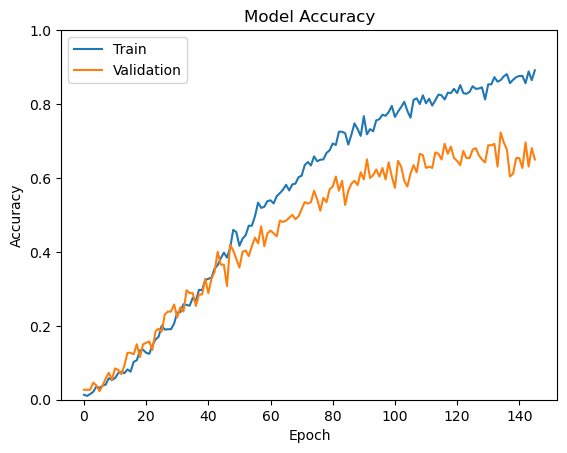

In [26]:

# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.legend(['Train', 'Validation'], loc='upper left')
save_plt = plt
plt.show()



In [28]:
data_directory = '../all_outputs/output_ssl_small/'

# list all the files in directories and sub directories in in data_direcotiry and store them list_list list
ft_file_names = []

for root, _, files in os.walk(data_directory):  # Walk through all directories and subdirectories
        for filename in files:
            ft_file_names.append(os.path.join(root, filename))

print(len(ft_file_names))                     

945
